In [1]:
import pandas as pd
import numpy as np
import cobra

In [10]:
# loading both datasets 
#geo_df  = pd.read_csv("GSE50760_norm_counts_TPM_GRCh38.p13_NCBI.tsv", sep="\t", index_col=0
tcga_data_path = "/Users/valentinreateguirangel/dissertation_project/data/TCGA/TCGA-COAD.star_tpm.tsv.gz.tsv"
tcga_df = pd.read_csv(tcga_data_path, sep="\t", index_col=0, compression="gzip")

## Data exploration

In [15]:
#TCGA size
print(tcga_df.shape)

(60660, 514)


In [19]:
# Checkin for NA values 
print(tcga_df.isna().sum().sum())

0


In [21]:
# Checking for duplicates 
print(tcga_df.index.duplicated().sum())    

0


## Data standarization 

In [28]:
# Remove vesrion numbers .00
tcga_df.index = tcga_df.index.str.split('.').str[0]

In [30]:
# Checkinf for duplicates
print(tcga_df.index.duplicated().sum())   

44


In [32]:
# Get the duplicated index values
duplicated_indices = tcga_df.index[tcga_df.index.duplicated()]
print(duplicated_indices)

Index(['ENSG00000002586', 'ENSG00000124333', 'ENSG00000124334',
       'ENSG00000167393', 'ENSG00000169084', 'ENSG00000169093',
       'ENSG00000169100', 'ENSG00000178605', 'ENSG00000182162',
       'ENSG00000182378', 'ENSG00000182484', 'ENSG00000185203',
       'ENSG00000185291', 'ENSG00000185960', 'ENSG00000196433',
       'ENSG00000197976', 'ENSG00000198223', 'ENSG00000205755',
       'ENSG00000214717', 'ENSG00000223274', 'ENSG00000223484',
       'ENSG00000223511', 'ENSG00000223571', 'ENSG00000223773',
       'ENSG00000225661', 'ENSG00000226179', 'ENSG00000227159',
       'ENSG00000228410', 'ENSG00000228572', 'ENSG00000229232',
       'ENSG00000230542', 'ENSG00000234622', 'ENSG00000234958',
       'ENSG00000236017', 'ENSG00000236871', 'ENSG00000237040',
       'ENSG00000237531', 'ENSG00000237801', 'ENSG00000265658',
       'ENSG00000270726', 'ENSG00000275287', 'ENSG00000277120',
       'ENSG00000280767', 'ENSG00000281849'],
      dtype='object', name='Ensembl_ID')


In [34]:
# Get all rows with duplicated indices (including the first occurrence)
duplicates_df = tcga_df.loc[tcga_df.index.isin(duplicated_indices)]
display(duplicates_df)

,TCGA-5M-AAT6-01A,TCGA-AA-3552-01A,TCGA-AA-3867-01A,TCGA-AD-6895-01A,TCGA-AA-3560-01A,TCGA-CM-6676-01A,TCGA-AA-A029-01A,TCGA-AA-A01C-01A,TCGA-CK-5912-01A,TCGA-AA-A03F-01A,...,TCGA-AD-6890-01A,TCGA-QL-A97D-01A,TCGA-AZ-6608-01A,TCGA-AA-A024-01A,TCGA-G4-6294-01A,TCGA-AZ-6601-01A,TCGA-AA-3672-01A,TCGA-AA-3524-01A,TCGA-AA-3715-01A,TCGA-AA-3531-01A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000002586,6.580828,7.112022,7.733805,7.676882,7.087260,7.460622,7.033177,7.111322,7.488841,6.680371,...,7.522506,6.012902,6.261612,6.003368,6.405000,6.968834,5.982049,7.645969,6.083573,6.794287
ENSG00000002586,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000124333,5.844089,5.503851,5.768253,5.396916,4.270447,6.401810,4.888514,5.328736,6.399092,2.894119,...,5.679854,5.678548,5.928752,4.411250,6.652911,6.619348,4.130082,5.695846,4.326257,5.445349
ENSG00000124333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000124334,0.636915,0.299948,0.095182,0.874836,0.095317,0.126180,0.140124,0.000000,0.056029,0.554638,...,0.451646,0.311968,0.066399,0.074231,0.072723,0.565597,2.063676,0.214000,0.582652,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000277120,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000280767,0.000000,0.000000,1.410612,0.000000,0.000000,0.374511,0.994218,0.647913,0.000000,0.000000,...,0.261350,0.334454,0.653243,0.597889,0.910579,0.790105,1.393855,0.000000,0.000000,0.468114
ENSG00000280767,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [36]:
# Getting only duplicated rows for processing 
duplicate_rows = tcga_df.loc[duplicated_indices]

In [38]:
# Keeping only non "0"
non_zero_duplicates = duplicate_rows.loc[~(duplicate_rows == 0).all(axis=1)]

In [40]:
# Droping duplicates with all "0"
tcga_df_cleaned = tcga_df.drop(index= duplicated_indices)
tcga_df_cleaned = pd.concat([tcga_df_cleaned, non_zero_duplicates])

In [42]:
# Sorting out index
tcga_df_cleaned = tcga_df_cleaned.sort_index()

In [44]:
# Checking for duplicates
print(tcga_df_cleaned.index.duplicated().sum())    

0


## Adding gene ID to TCGA data

In [47]:
# Mapping ensembl ID to gene ID susing BioMart
#print (geo_df.head())

In [49]:
# importing dataset from BioMart with gene ID, NCBI and gene name.
#mapping_df = pd.read_csv("mart_export.txt", sep=",")
# Renaming for clarity
#mapping_df.columns = ['Ensembl_ID', 'GeneID', 'Gene_Name']
#print (mapping_df.head())

In [51]:
# Since there are Ensembl ID entreis withough Gene ID, I am dropping entries without GeneID (Entrez number)
#mapping_df = mapping_df.dropna(subset=["GeneID"])
#print (mapping_df.head())

In [53]:
# Merging mapping_df with TCGA data 
#tcga_mapped = pd.merge(tcga_df_cleaned, mapping_df[['Ensembl_ID', 'GeneID']], on='Ensembl_ID')
# Set GeneID as index
#tcga_mapped = tcga_mapped.set_index('GeneID')
#tcga_mapped = tcga_mapped.drop(columns=['Ensembl_ID'])
#print(tcga_mapped.head())

In [55]:
#print(tcga_mapped.shape)
#tcga_mapped.index = tcga_mapped.index.astype(int)

### Relabeling TCGA data

In [59]:
# Relabeling function
def label_tcga(col):
    try:
        parts = col.split('-')
        if len(parts) < 4:
            return f"TCGA_{col}"
        sample_code = parts[3][:2]
        condition = "Tumor" if sample_code == "01" else "Healthy" if sample_code == "11" else "Other"
        patient_id = parts[2]  
        return f"TCGA_{condition}_{patient_id}"
    except:
        return f"TCGA_Unknown_{col}"

In [61]:
tcga_labeled = tcga_df_cleaned.copy()
tcga_labeled.columns = [label_tcga(col) for col in tcga_labeled.columns]

In [63]:
print (tcga_labeled.head())
print(tcga_labeled.index.duplicated().sum())   

                 TCGA_Tumor_AAT6  TCGA_Tumor_3552  TCGA_Tumor_3867  \
Ensembl_ID                                                           
ENSG00000000003         4.783671         7.069015         7.627462   
ENSG00000000005         0.343692         0.753776         0.300417   
ENSG00000000419         6.679223         6.679985         7.430763   
ENSG00000000457         2.640366         2.605779         2.751292   
ENSG00000000460         2.678906         1.893168         2.264747   

                 TCGA_Tumor_6895  TCGA_Tumor_3560  TCGA_Tumor_6676  \
Ensembl_ID                                                           
ENSG00000000003         4.079737         7.155694         7.634865   
ENSG00000000005         0.000000         2.463518         4.400080   
ENSG00000000419         6.839957         6.019186         8.255367   
ENSG00000000457         3.088125         2.570706         3.005328   
ENSG00000000460         2.415056         2.718548         2.587629   

                 T

## Model  TCGA
TCGA, it will be relabeled and then converted in to single vectors for iMat

In [66]:
tcga_only= tcga_labeled.copy()

In [68]:
# Relabeling using previous function def.label_tcga 
tcga_only.columns = [label_tcga(col) for col in tcga_only.columns]

Check for duble values also analysing the values dristribution fo the gene expressions 

In [71]:
# Spliting healhty to tumour, spliting by column label
tcga_tumor_df   = tcga_only.loc[:, tcga_only.columns.str.contains("Tumor")]
tcga_healthy_df = tcga_only.loc[:, tcga_only.columns.str.contains("Healthy")]

In [73]:
print (tcga_tumor_df.shape)
print (tcga_healthy_df.shape)

(60616, 471)
(60616, 41)


#### Data Visualization 

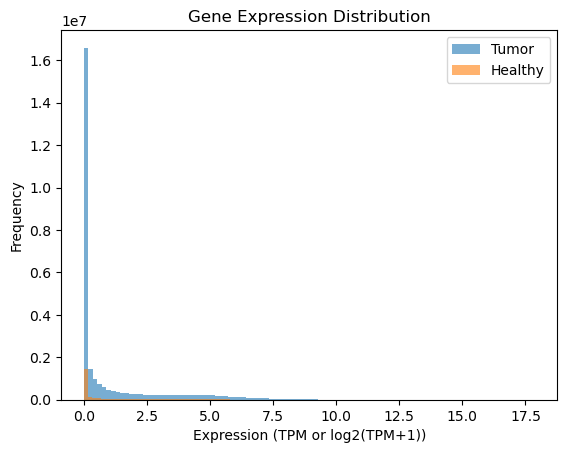

In [76]:
import matplotlib.pyplot as plt

# Flatten the values into one array per dataset
tumor_vals = tcga_tumor_df.values.flatten()
healthy_vals = tcga_healthy_df.values.flatten()

plt.hist(tumor_vals, bins=100, alpha=0.6, label='Tumor')
plt.hist(healthy_vals, bins=100, alpha=0.6, label='Healthy')
plt.xlabel("Expression (TPM or log2(TPM+1))")
plt.ylabel("Frequency")
plt.title("Gene Expression Distribution")
plt.legend()
plt.show()

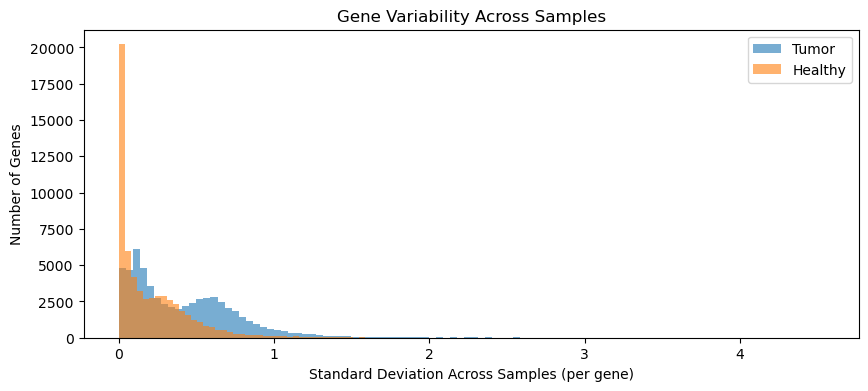

In [78]:
# Standard deviation across genes 
tumor_gene_std = tcga_tumor_df.std(axis=1)
healthy_gene_std = tcga_healthy_df.std(axis=1)

plt.figure(figsize=(10,4))
plt.hist(tumor_gene_std, bins=100, alpha=0.6, label='Tumor')
plt.hist(healthy_gene_std, bins=100, alpha=0.6, label='Healthy')
plt.xlabel("Standard Deviation Across Samples (per gene)")
plt.ylabel("Number of Genes")
plt.title("Gene Variability Across Samples")
plt.legend()
plt.show()

### PCA to see diversity among all tumor samples 

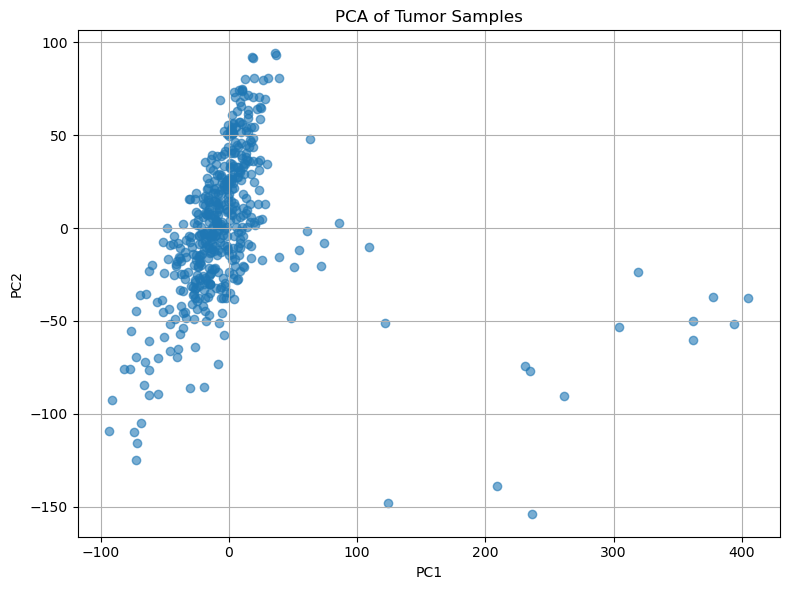

In [81]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Transpose: now samples are rows
tumor_data = tcga_tumor_df.T

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(tumor_data)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6)
plt.title("PCA of Tumor Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

### PCA to see diversity among all healthy samples 

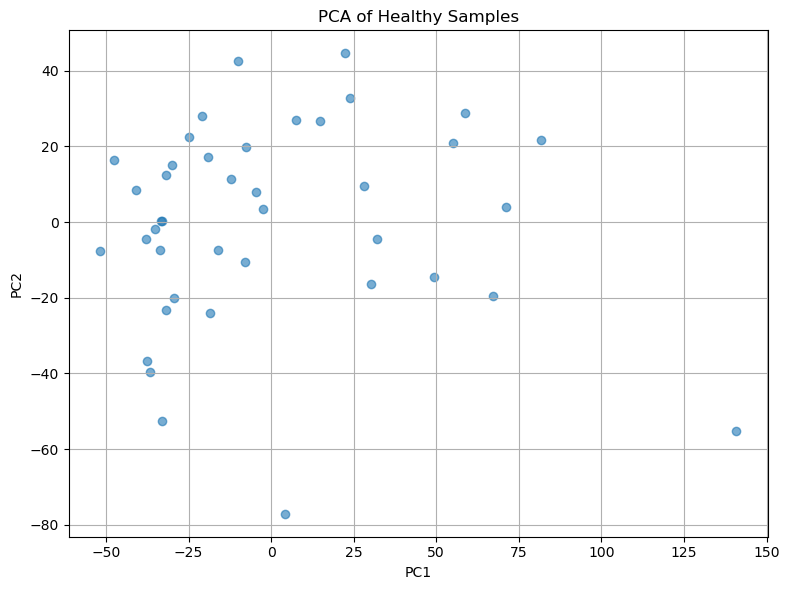

In [84]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Transpose: now samples are rows
healthy_data = tcga_healthy_df.T

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(healthy_data)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6)
plt.title("PCA of Healthy Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

## Density and Ambiguity plots 

In [87]:
# Desnsity plot of al TPM values in the data (All genes x )
# Flattening data 
tpm_values = tcga_only.values.flatten()

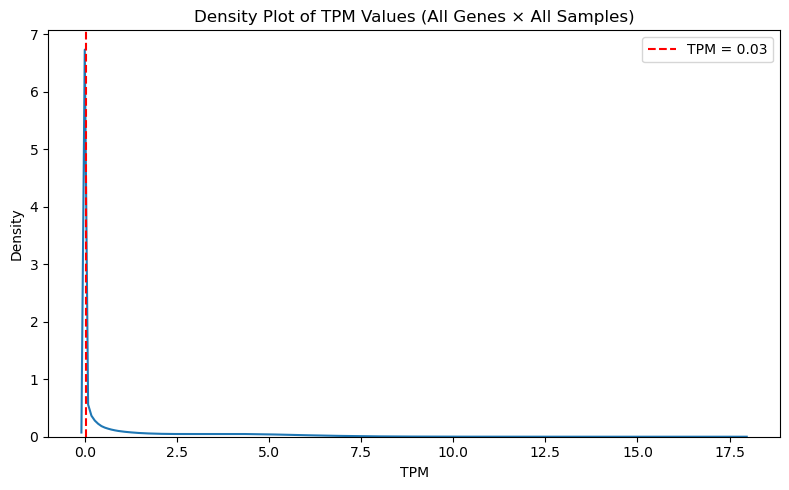

In [89]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(tpm_values, bw_adjust=0.5)
plt.axvline(0.03, color='red', linestyle='--', label='TPM = 0.03')
plt.title("Density Plot of TPM Values (All Genes × All Samples)")
plt.xlabel("TPM")
plt.ylabel("Density")
#plt.xscale('log') 
plt.legend()
plt.tight_layout()
plt.show()

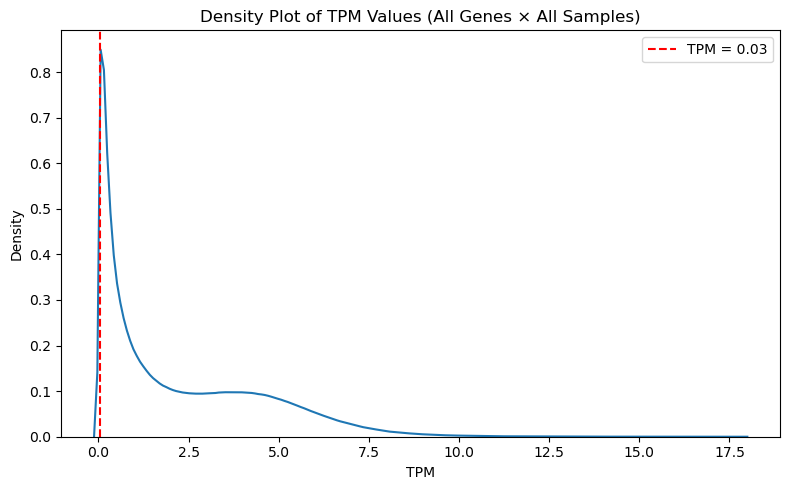

In [91]:
# Density plot, filtering values = 0 or negatives if they exist 
tpm_threshold_value = tpm_values[tpm_values > 0]

plt.figure(figsize=(8, 5))
sns.kdeplot(tpm_threshold_value, bw_adjust=0.5)
plt.axvline(0.03, color='red', linestyle='--', label='TPM = 0.03')
plt.title("Density Plot of TPM Values (All Genes × All Samples)")
plt.xlabel("TPM")
plt.ylabel("Density")
#plt.xscale('log')  
plt.legend()
plt.tight_layout()
plt.show()

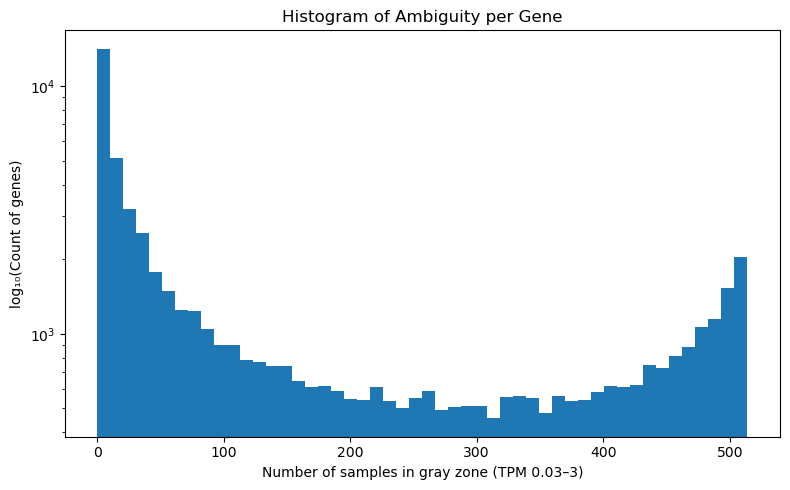

In [93]:
# Histogram of ambiguity per gene 
# Define gray zone thresholds
lower_thresh = 0.03
upper_thresh = 3

# Count ambiguity per gene, samples in the grey zone
ambiguity_counts = tcga_only.apply(lambda row: ((row >= lower_thresh) & (row <= upper_thresh)).sum(), axis=1)

# Histogram (log scale on y-axis)
plt.figure(figsize=(8, 5))
plt.hist(ambiguity_counts, bins=50)
plt.yscale('log')
plt.title("Histogram of Ambiguity per Gene")
plt.xlabel("Number of samples in gray zone (TPM 0.03–3)")
plt.ylabel("log₁₀(Count of genes)")
plt.tight_layout()
plt.show()

In [95]:
print (ambiguity_counts)

Ensembl_ID
ENSG00000000003      1
ENSG00000000005    432
ENSG00000000419      0
ENSG00000000457    328
ENSG00000000460    389
                  ... 
ENSG00000288669     20
ENSG00000288670    218
ENSG00000288671      0
ENSG00000288674    312
ENSG00000288675    510
Length: 60616, dtype: int64


## Full set & 90 ambiguity pure, (Tumor and healhty each)

#### Picking genes with at least 90% pure of ambiguity values 
Will clear noisy genes and retain a clean mayority。

In [99]:
# Number of samples
n_samples = tcga_only.shape[1]

# Defining ambiguity theshold (70% of total sample count)
max_ambigous = int(n_samples * 0.70)

In [103]:
# Ambiguity filter 
# Mask for genes with <= 70% ambiguity
keep_genes_mask = ambiguity_counts <= max_ambigous 

# Applying 
less_ambigous_tcga = tcga_only.loc[keep_genes_mask]

In [105]:
# Check how many genes remain
print(f"Original genes: {tcga_only.shape[0]}")
print(f"Filtered genes: {less_ambigous_tcga.shape[0]}")

Original genes: 60616
Filtered genes: 47595


### No filering , full ambigous

In [108]:
full_ambigous = tcga_only.copy()
print(f"Full ambigous genes: {full_ambigous.shape[0]}")

Full ambigous genes: 60616


# Discrete Model
Row-wise 25th/75th percentile to +-1/0, assigning per-sample ±1/0/–1 labels with the 25ᵗʰ/75ᵗʰ-percentile rule

In [111]:
# Discreatizing function 
def discretize_row(row): 
    q25 = row.quantile(0.25)
    q75 = row.quantile(0.75)
    return row.apply(lambda x : 1 if x >= q75 else ( -1 if x <= q25 else 0 ) )

### Discretising for less ambigous 

In [114]:
# applying function
tcga_discrete = less_ambigous_tcga.apply(discretize_row, axis=1)
print(f"Less ambigous genes: {tcga_discrete.shape[0]}")

Less ambigous genes: 47595


### Discreising for full ambigous

In [117]:
# applying function
tcga_discrete_ambigous = full_ambigous.apply(discretize_row, axis=1)
print(f"Full ambigous genes: {tcga_discrete_ambigous.shape[0]}")

Full ambigous genes: 60616


### Spliting main data to tumor and healthy

In [120]:
# Less ambigous
tcga_tumor   = tcga_discrete.loc[:, tcga_only.columns.str.contains("Tumor")]
tcga_healthy = tcga_discrete.loc[:, tcga_only.columns.str.contains("Healthy")]

# Full ambigous
tcga_tumor_amb   = tcga_discrete_ambigous.loc[:, tcga_only.columns.str.contains("Tumor")]
tcga_healthy_amb = tcga_discrete_ambigous.loc[:, tcga_only.columns.str.contains("Healthy")]

### Collapsing Datasets for iMat

Collapsing to one vector each tcga dataframe , same approach used by FASTCORMICS :
- If ≥90% of samples have +1 ----> final value = +1
- If ≥90% of samples have -1 ----> final value = -1
- Else ----> final value = 0

In [123]:
# Fascormics function like
def collapse_by_voting(df):
    def vote(row):
        total = len(row)
        count_pos = (row == 1).sum()
        count_neg = (row == -1).sum()
        if count_pos / total >= 0.7:
            return 1
        elif count_neg / total >= 0.7:
            return -1
        else:
            return 0
    return df.apply(vote, axis=1)

In [125]:
# Applying fucntion less ambigous 
tumor_vector = collapse_by_voting(tcga_tumor)
healthy_vector = collapse_by_voting(tcga_healthy)

In [127]:
# Applying fucntion full ambigous 
tumor_vector_amb = collapse_by_voting(tcga_tumor_amb)
healthy_vector_amb = collapse_by_voting(tcga_healthy_amb)

### Visual exploration of the data 

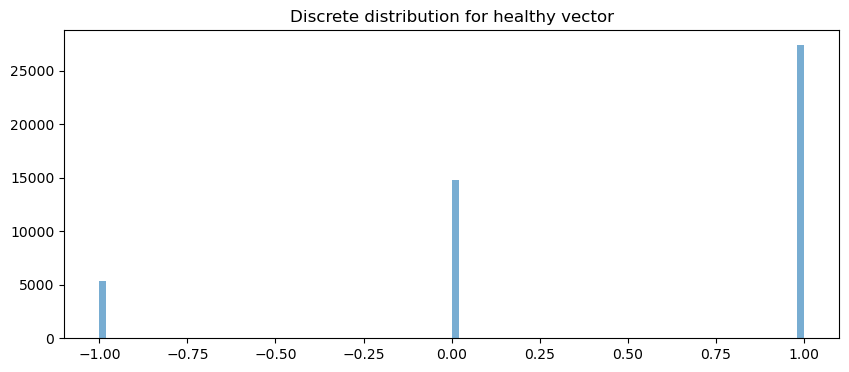

In [130]:
# Data visualization for Healhty less ambigous
plt.figure(figsize=(10,4))
plt.hist(healthy_vector, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for healthy vector")
plt.show()

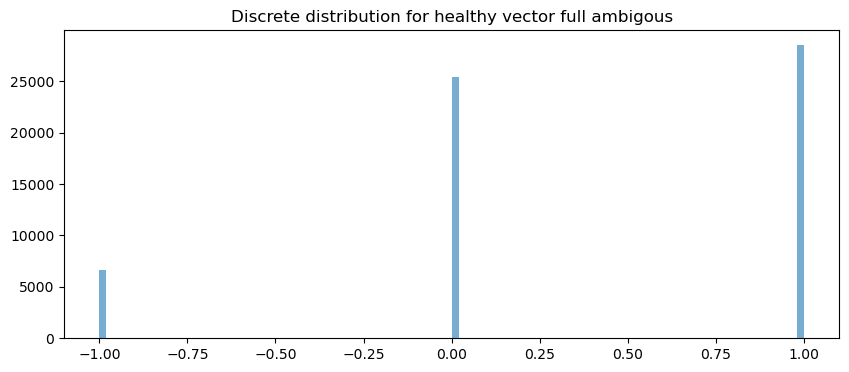

In [132]:
# Data visualization for Healhty full ambigous

plt.figure(figsize=(10,4))
plt.hist(healthy_vector_amb, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for healthy vector full ambigous")
plt.show()

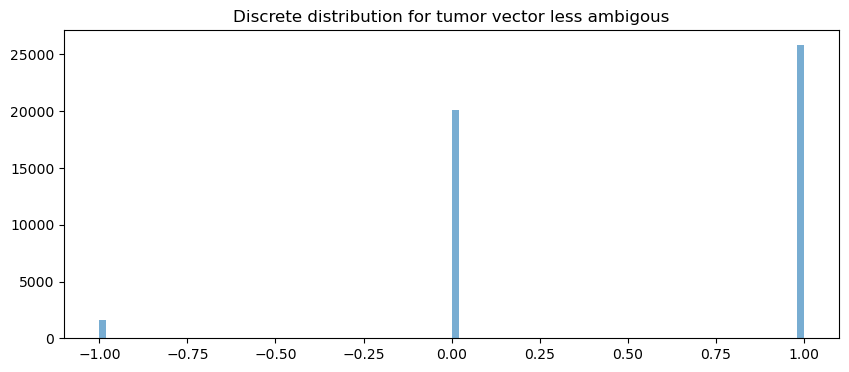

In [134]:
# Data visualization for tumor less ambigous

plt.figure(figsize=(10,4))
plt.hist(tumor_vector, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for tumor vector less ambigous")
plt.show()

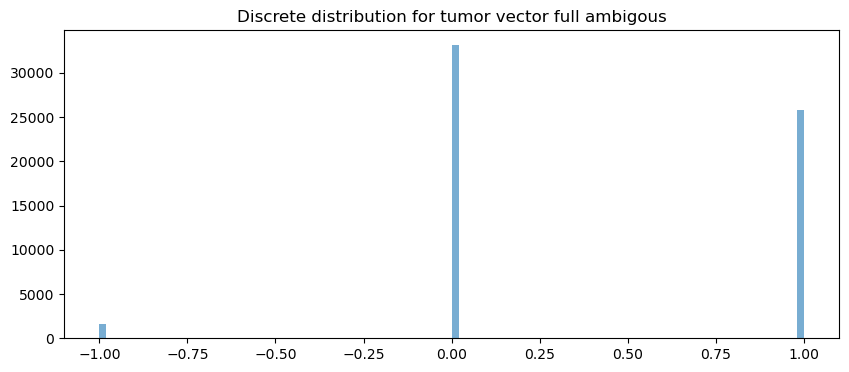

In [136]:
# Data visualization for tumor full ambigous
plt.figure(figsize=(10,4))
plt.hist(tumor_vector_amb, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for tumor vector full ambigous")
plt.show()

Data needs to be formated to be suitable for matlab

In [139]:
# Reformating 
#For tumor 
tumor_vector_df = tumor_vector.reset_index()
tumor_vector_df.columns = ['GeneID', 'Expression']

tumor_vector_amb_df = tumor_vector_amb.reset_index()
tumor_vector_amb_df.columns = ['GeneID', 'Expression']

#For healthy
healthy_vector_df = healthy_vector.reset_index()
healthy_vector_df.columns = ['GeneID', 'Expression']

healthy_vector_amb_df = healthy_vector_amb.reset_index()
healthy_vector_amb_df.columns = ['GeneID', 'Expression']


In [143]:
# Exporting values 
tumor_vector_df.to_csv("tumor_expression_vector70.txt", sep="\t", index=False, header=False)
healthy_vector_df.to_csv("healthy_expression_vector70.txt", sep="\t", index=False, header=False)

tumor_vector_amb_df.to_csv("tumor_expression_vector_full.txt", sep="\t", index=False, header=False)
healthy_vector_amb_df.to_csv("healthy_expression_vector_full.txt", sep="\t", index=False, header=False)


# Continuous Models 

In [ ]:
tumor_vector.shape
print(f"Full ambigous genes: {tumor_vector.shape[0]}")

In [ ]:
tumor_vector_amb.shape
print(f"Full ambigous genes: {tumor_vector_amb.shape[0]}")

In [ ]:
# Boolean mask: True where all values in the row are 0
all_zero_genes = (tcga_only == 0).all(axis=1)

# Extract gene IDs
zero_gene_ids = tcga_only.index[all_zero_genes]

# How many?
print(f"Number of genes with all zeros: {all_zero_genes.sum()}")

# Optional: preview
print(zero_gene_ids)

In [ ]:
# Dropping genes with 0 value across all the columns 

all_zero_genes = (tcga_only == 0).all(axis=1)

# Step 2: Drop them
tcga_only = tcga_only.loc[~all_zero_genes]

# Step 3 (optional): Confirm new shape
print(f"Filtered shape: {tcga_only.shape}")

In [ ]:
# Spliting datasets 
# Less ambigous
tcga_cont_tumor   = less_ambigous_tcga.loc[:, tcga_only.columns.str.contains("Tumor")]
tcga_cont_healthy = less_ambigous_tcga.loc[:, tcga_only.columns.str.contains("Healthy")]

# Full ambigous
tcga_cont_full_tumor   = full_ambigous.loc[:, tcga_only.columns.str.contains("Tumor")]
tcga_cont_full_healthy = full_ambigous.loc[:, tcga_only.columns.str.contains("Healthy")]

## Median method

In [ ]:
# Calculating median across both datasets full ambigous and less 
# Less ambigous 
tcga_less_continuous_healthy_median = tcga_cont_healthy.median(axis=1)
tcga_less_continuous_tumor_median = tcga_cont_tumor .median(axis=1)

# Full ambigous 
tcga_full_continuous_healthy_median = tcga_cont_full_healthy.median(axis=1)
tcga_full_continuous_tumor_median = tcga_cont_full_tumor.median(axis=1)

## Data visualization 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution of Median Gene Expression", fontsize=16)

# Top-left
sns.histplot(tcga_less_continuous_healthy_median, bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Less Ambiguous - Healthy")
axes[0, 0].set_xlabel("Expression")
axes[0, 0].set_ylabel("Gene Count")

# Top-right
sns.histplot(tcga_less_continuous_tumor_median, bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Less Ambiguous - Tumor")
axes[0, 1].set_xlabel("Expression")
axes[0, 1].set_ylabel("Gene Count")

# Bottom-left
sns.histplot(tcga_full_continuous_healthy_median, bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Full Ambiguous - Healthy")
axes[1, 0].set_xlabel("Expression")
axes[1, 0].set_ylabel("Gene Count")

# Bottom-right
sns.histplot(tcga_full_continuous_tumor_median, bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Full Ambiguous - Tumor")
axes[1, 1].set_xlabel("Expression")
axes[1, 1].set_ylabel("Gene Count")

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Exporting data 

In [ ]:
# Reformating 
#For Full data 
tcga_full_continuous_tumor_median = tcga_full_continuous_tumor_median.reset_index()
tcga_full_continuous_tumor_median.columns = ['GeneID', 'Expression']

tcga_full_continuous_healthy_median = tcga_full_continuous_healthy_median.reset_index()
tcga_full_continuous_healthy_median.columns = ['GeneID', 'Expression']

#For less ambigous
tcga_less_continuous_tumor_median = tcga_less_continuous_tumor_median.reset_index()
tcga_less_continuous_tumor_median.columns = ['GeneID', 'Expression']

tcga_less_continuous_healthy_median = tcga_less_continuous_healthy_median.reset_index()
tcga_less_continuous_healthy_median.columns = ['GeneID', 'Expression']


In [ ]:
# Exporting values 
# Full data
tcga_full_continuous_tumor_median.to_csv("tumor_full_median_expression_vector.txt", sep="\t", index=False, header=False)
tcga_full_continuous_healthy_median.to_csv("healthy__full_median_expression_vector.txt", sep="\t", index=False, header=False)

# Less ambigous
tcga_less_continuous_tumor_median.to_csv("tumor_less_median_expression_vector_amb.txt", sep="\t", index=False, header=False)
tcga_less_continuous_healthy_median.to_csv("healthy_less_median_expression_vector_amb.txt", sep="\t", index=False, header=False)

# Z score experiment

In [ ]:
# Calculate the median and range for each gene
gene_medians = tcga_only.median(axis=1)
gene_max = tcga_only.max(axis=1)
gene_min = tcga_only.min(axis=1)
gene_range = gene_max - gene_min

# Combine into a single DataFrame for inspection
range_df = pd.DataFrame({
    "median": gene_medians,
    "min": gene_min,
    "max": gene_max,
    "range": gene_range
})

# Sort to see genes with low median but high range
interesting_genes = range_df.sort_values(by=["median", "range"], ascending=[True, False])

# Show
print(interesting_genes.shape[0])
print(interesting_genes.head())

In [ ]:
# Estimate "off-state" gene expression across ALL samples
off_mean = tcga_only.mean(axis=1)
off_std  = tcga_only.std(axis=1)

# Convert mean and std Series to NumPy arrays before 
z_scores = (tcga_only - off_mean.to_numpy().reshape(-1, 1)) / off_std.to_numpy().reshape(-1, 1)

z_scores

In [ ]:
# Flatten all values (ignore NaNs)
z_flat = z_scores.values.flatten()
z_flat = z_flat[~np.isnan(z_flat)]  # Remove NaNs

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.histplot(z_flat, bins=100, kde=True)
#plt.yscale('log')
plt.title("Distribution of Z-Scores (All Genes × All Tumor Samples)")
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.axvline(0, color='black', linestyle='--', label='(z=0)')
plt.axvline(0.03, color='green', linestyle='--', label='z = +1')
plt.axvline(-0.03, color='red', linestyle='--', label='z = -1')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Spliting Z-score matrix into tumor and healthy samples
z_tumor   = z_scores.loc[:, z_scores.columns.str.contains("Tumor")]
z_healthy = z_scores.loc[:, z_scores.columns.str.contains("Healthy")]

In [ ]:
# Distribution after spliting 
# Flatten Z-scores, remove NaNs
z_tumor_flat = z_tumor.values.flatten()
z_tumor_flat = z_tumor_flat[~np.isnan(z_tumor_flat)]

z_healthy_flat = z_healthy.values.flatten()
z_healthy_flat = z_healthy_flat[~np.isnan(z_healthy_flat)]

# Plot side-by-side
plt.figure(figsize=(14, 5))

# Tumor
plt.subplot(1, 2, 1)
sns.histplot(z_tumor_flat, bins=100, kde=True)
plt.title("Z-Score Distribution: Tumor Samples")
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.axvline(0, color='black', linestyle='--', label='z = 0')
plt.axvline(1, color='green', linestyle='--', label='z = +1')
plt.axvline(-1, color='red', linestyle='--', label='z = -1')
plt.legend()

# Healthy
plt.subplot(1, 2, 2)
sns.histplot(z_healthy_flat, bins=100, kde=True)
plt.title("Z-Score Distribution: Healthy Samples")
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.axvline(0, color='black', linestyle='--', label='z = 0')
plt.axvline(1, color='green', linestyle='--', label='z = +1')
plt.axvline(-1, color='red', linestyle='--', label='z = -1')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Collapsing into +1,-1 and 0 
# Collapsing fucntion 
def collapse_to_imat_vector(z_df, thresh= 0.5, ratio=0.25):
    expressed = (z_df >  thresh).sum(axis=1)
    unexpressed = (z_df < -thresh).sum(axis=1)
    total = (~z_df.isna()).sum(axis=1)
    
    imat_vector = np.zeros(z_df.shape[0])
    imat_vector[expressed / total >= ratio] = 1
    imat_vector[unexpressed / total >= ratio] = -1
    return imat_vector

In [ ]:
# Collapse
imat_vector_tumor   = collapse_to_imat_vector(z_tumor)
imat_vector_healthy = collapse_to_imat_vector(z_healthy)

In [ ]:
import matplotlib.pyplot as plt

# Count values
tumor_counts = pd.Series(imat_vector_tumor).value_counts().sort_index()
healthy_counts = pd.Series(imat_vector_healthy).value_counts().sort_index()

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Tumor
axes[0].bar(tumor_counts.index.astype(str), tumor_counts.values, color='tomato')
axes[0].set_title("Tumor iMAT Vector")
axes[0].set_xlabel("Expression category")
axes[0].set_ylabel("Gene count")

# Healthy
axes[1].bar(healthy_counts.index.astype(str), healthy_counts.values, color='teal')
axes[1].set_title("Healthy iMAT Vector")
axes[1].set_xlabel("Expression category")

plt.tight_layout()
plt.show()

In [ ]:
# Reformat for MATLAB
imat_vector_tumor = pd.DataFrame({
    'GeneID': z_tumor.index,
    'Expression': imat_vector_tumor
}).reset_index(drop=True)

imat_vector_healthy = pd.DataFrame({
    'GeneID': z_healthy.index,
    'Expression': imat_vector_healthy
}).reset_index(drop=True)

In [ ]:
# Exporting for MATLAB
output_path = "/Users/valentinreateguirangel/dissertation_project/Z score model"

# Export tumor
pd.DataFrame(imat_vector_tumor).to_csv(
    output_path + "imat_vector_tumor.txt", sep="\t", index=False, header=False)

# Export healthy
pd.DataFrame(imat_vector_healthy).to_csv(
    output_path + "imat_vector_healthy.txt", sep="\t", index=False, header=False)

In [ ]:
pd.DataFrame(imat_vector_tumor).value_counts()